# 03 - First derivative (catch the take-off)

**The idea:** the daily signal is bumpy. We smooth it, then take the
**first derivative** = how much it changed since yesterday (think 'speed').
When that speed jumps well above normal, attention is accelerating - that is
the inflection / take-off point. We mark those days in red.

You can run this on EITHER signal from notebook 02 by setting `VALUE_COLUMN`:
`mention_count` (raw) or `weighted_count` (upvote-weighted).

Reads `data/processed/daily_ticker_counts.parquet` (made by notebook 02).

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [2]:
# ============ PARAMETERS - edit these ============
DAILY_COUNTS_PATH = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts.parquet')
VALUE_COLUMN      = 'mention_count'   # 'mention_count' (raw) or 'weighted_count' (by upvotes)
TICKERS           = []     # e.g. ['GME']; [] = use the TOP_N most mentioned
TOP_N             = 10
SMOOTH            = 3      # rolling-average window in days (bigger = calmer)
K                 = 2.0    # std-devs above/below normal that counts as a rise/fall spike
# ==================================================

In [3]:
# ============ TIME WINDOW - edit freely ============
# Clips the daily counts before the analysis. None = keep everything in the
# counts file (which was already windowed when notebook 02/04 produced it).
START_DATE = None   # inclusive,  'YYYY-MM-DD' or None
END_DATE   = None   # EXCLUSIVE,  'YYYY-MM-DD' or None
# ====================================================

In [4]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Force-reload src.inflection every time this cell runs. Without this, a
# kernel that already imported the module earlier (e.g. before this file was
# last edited) keeps using the OLD cached version forever - editing the .py
# file on disk does NOT update an already-running kernel's import cache.
# That stale-cache mismatch is exactly what causes "KeyError: is_rise" /
# "is_rise is not defined" even though the source file is correct. This
# reload means you never have to remember to restart the kernel.
import importlib
import src.inflection
importlib.reload(src.inflection)
from src.inflection import build_daily_series, compute_inflection

def format_date_axis(ax, rotate=45):
    """Dense, unambiguous date ticks (YYYY-MM-DD), one per week, so you can
    read the exact week off any plot instead of matplotlib's sparser
    monthly default."""
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    for label in ax.get_xticklabels():
        label.set_rotation(rotate)
        label.set_ha('right')
        label.set_fontsize(7)
    ax.grid(True, which='major', axis='x', alpha=0.3)

daily = pd.read_parquet(DAILY_COUNTS_PATH)
daily['date'] = pd.to_datetime(daily['date'])

# Apply the time window from the cell above.
if START_DATE:
    daily = daily[daily['date'] >= pd.Timestamp(START_DATE)]
if END_DATE:
    daily = daily[daily['date'] < pd.Timestamp(END_DATE)]
print('window:', START_DATE, 'to', END_DATE, '|', len(daily), 'daily rows kept')

# If the chosen column is missing (e.g. real 2021 file has no upvotes), fall back.
if VALUE_COLUMN not in daily.columns:
    print('NOTE:', VALUE_COLUMN, 'not in this file - using mention_count instead.')
    VALUE_COLUMN = 'mention_count'

# Rank tickers by the SAME signal we are analysing.
if TICKERS:
    chosen = TICKERS
else:
    totals = daily.groupby('ticker')[VALUE_COLUMN].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('analysing:', chosen, '| signal:', VALUE_COLUMN)

window: None to None | 80931 daily rows kept
analysing: ['GME', 'AMC', 'SNDL', 'PLTR', 'TSLA', 'BB', 'CLOV', 'NAKD', 'NOK', 'SPCE'] | signal: mention_count



GME (mention_count): 5 rise day(s), 7 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-26 | value 914 | velocity 255.7
    RISE   2021-01-27 | value 2327 | velocity 732.0
    RISE   2021-01-28 | value 4281 | velocity 1264.7
    RISE   2021-01-29 | value 2179 | velocity 421.7
    RISE   2021-02-02 | value 2811 | velocity 428.7
    FALL   2021-01-30 | value 1525 | velocity -267.3
    FALL   2021-01-31 | value 1770 | velocity -837.0
    FALL   2021-02-04 | value 904 | velocity -631.0
    FALL   2021-02-05 | value 885 | velocity -642.0
    FALL   2021-02-06 | value 259 | velocity -307.3
    FALL   2021-02-07 | value 159 | velocity -248.3
    FALL   2021-02-08 | value 176 | velocity -236.3
    PEAK   2021-01-29


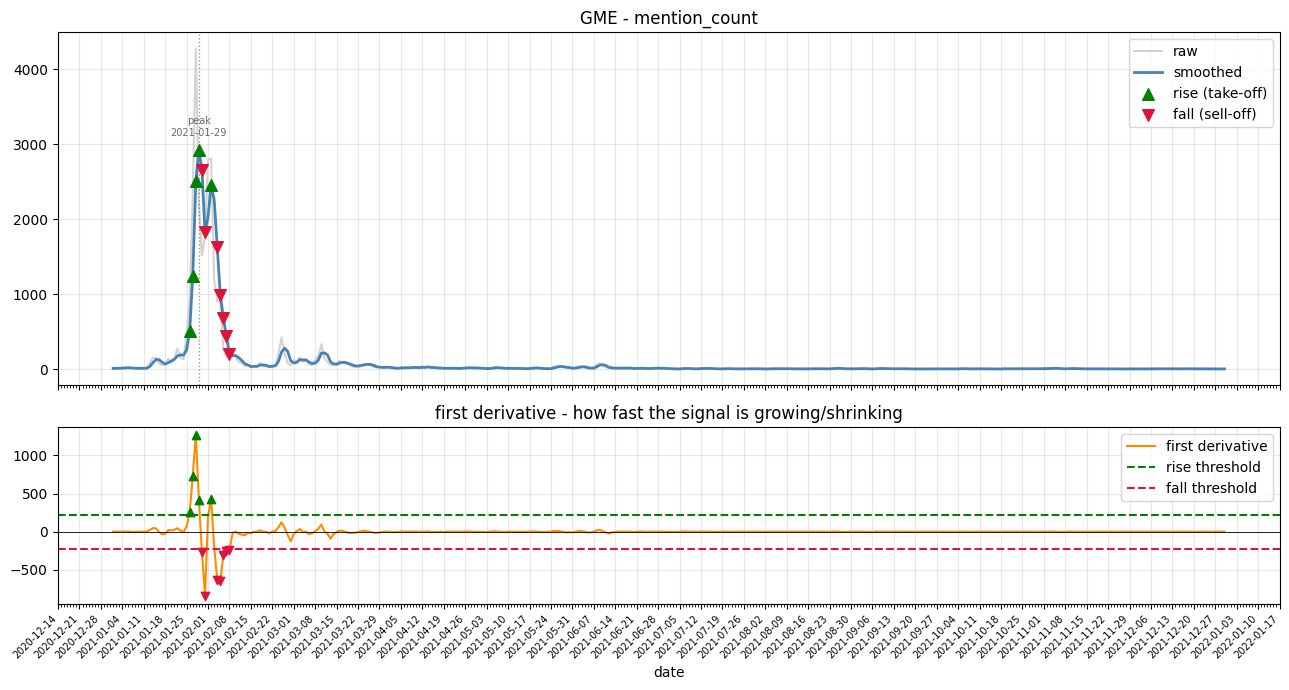


AMC (mention_count): 4 rise day(s), 5 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-27 | value 1127 | velocity 374.7
    RISE   2021-01-28 | value 1848 | velocity 581.3
    RISE   2021-01-29 | value 884 | velocity 237.3
    RISE   2021-02-02 | value 1175 | velocity 232.0
    FALL   2021-01-30 | value 479 | velocity -216.0
    FALL   2021-01-31 | value 492 | velocity -452.0
    FALL   2021-02-04 | value 227 | velocity -275.0
    FALL   2021-02-05 | value 251 | velocity -308.0
    FALL   2021-02-06 | value 91 | velocity -126.0
    PEAK   2021-01-29


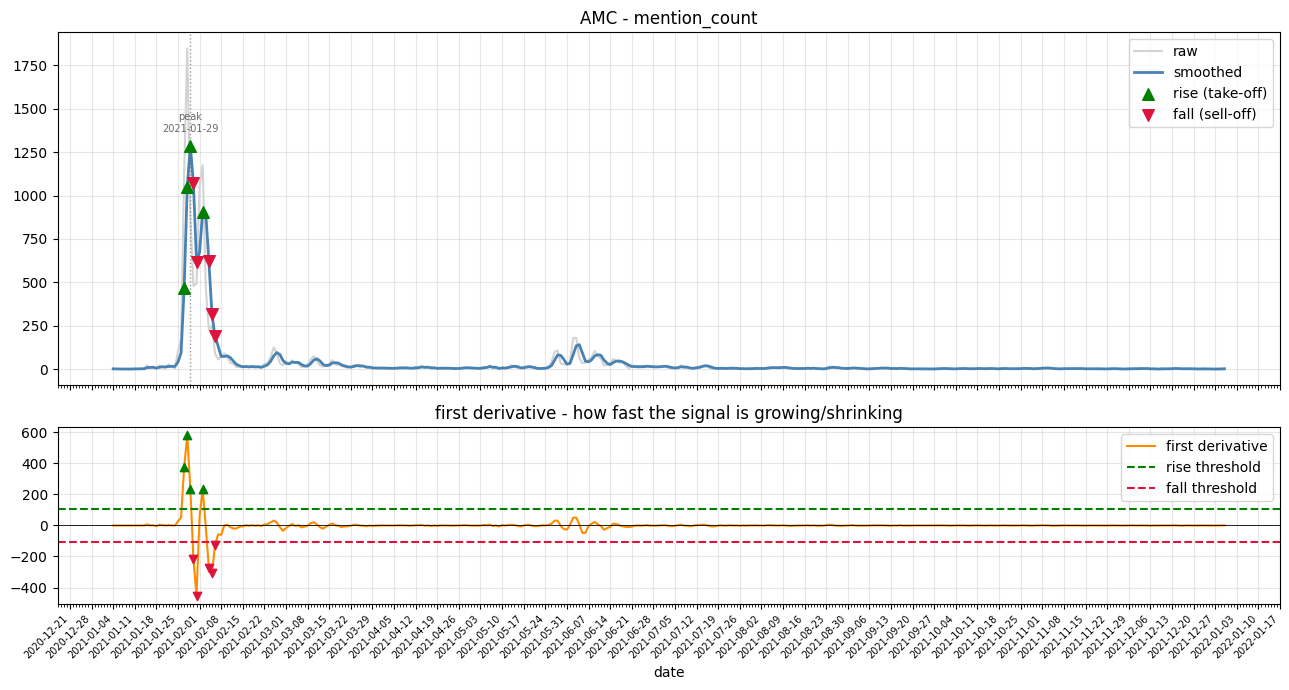


SNDL (mention_count): 5 rise day(s), 4 fall day(s), 2 peak(s), 1 trough(s)
    RISE   2021-01-27 | value 376 | velocity 123.7
    RISE   2021-01-28 | value 1795 | velocity 592.3
    RISE   2021-01-29 | value 758 | velocity 242.0
    RISE   2021-02-10 | value 1110 | velocity 357.3
    RISE   2021-02-11 | value 1212 | velocity 378.7
    FALL   2021-01-31 | value 176 | velocity -539.7
    FALL   2021-02-04 | value 221 | velocity -174.0
    FALL   2021-02-13 | value 89 | velocity -340.3
    FALL   2021-02-14 | value 57 | velocity -385.0
    PEAK   2021-01-29
    PEAK   2021-02-12
    TROUGH 2021-02-08


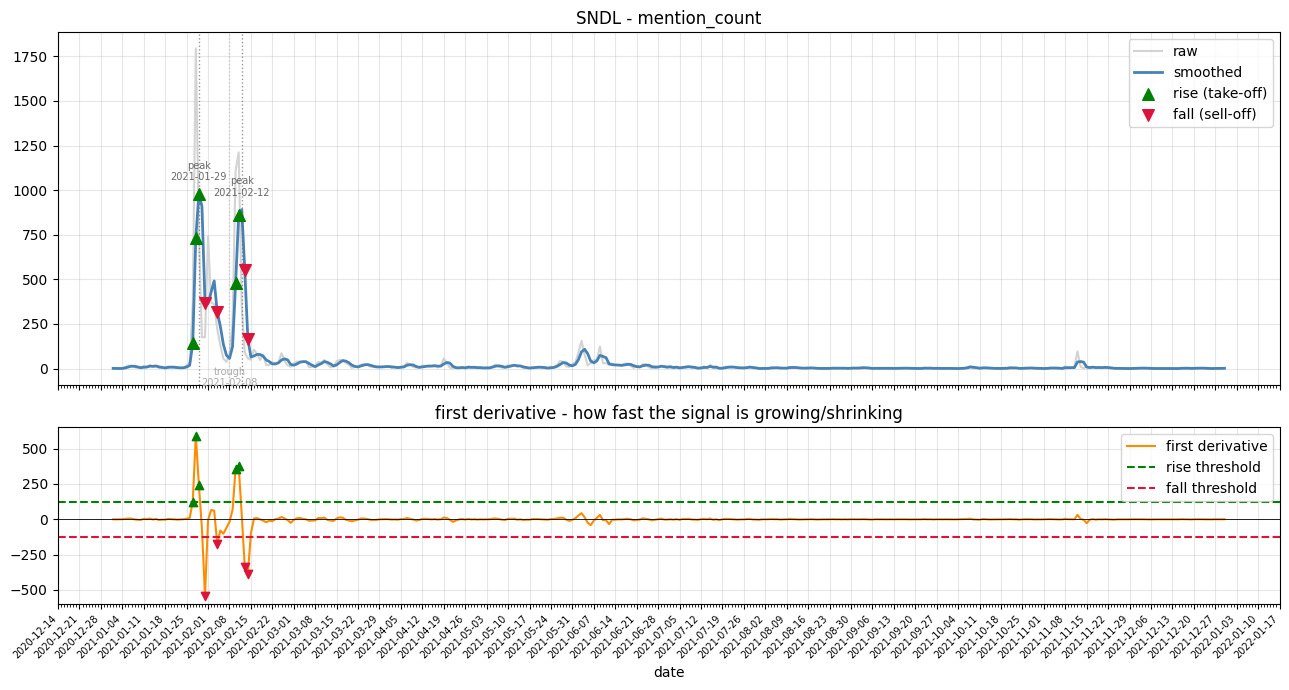


PLTR (mention_count): 9 rise day(s), 7 fall day(s), 2 peak(s), 1 trough(s)
    RISE   2021-01-13 | value 102 | velocity 26.0
    RISE   2021-01-15 | value 225 | velocity 61.3
    RISE   2021-01-22 | value 265 | velocity 65.3
    RISE   2021-01-23 | value 156 | velocity 34.0
    RISE   2021-01-27 | value 312 | velocity 76.3
    RISE   2021-02-16 | value 174 | velocity 44.0
    RISE   2021-02-17 | value 119 | velocity 30.7
    RISE   2021-02-18 | value 138 | velocity 30.0
    RISE   2021-02-19 | value 328 | velocity 51.3
    FALL   2021-01-18 | value 25 | velocity -66.7
    FALL   2021-01-29 | value 83 | velocity -45.0
    FALL   2021-01-30 | value 36 | velocity -92.0
    FALL   2021-01-31 | value 42 | velocity -52.7
    FALL   2021-02-22 | value 97 | velocity -77.0
    FALL   2021-02-28 | value 34 | velocity -29.0
    FALL   2021-03-07 | value 22 | velocity -33.3
    PEAK   2021-01-27
    PEAK   2021-02-19
    TROUGH 2021-02-07


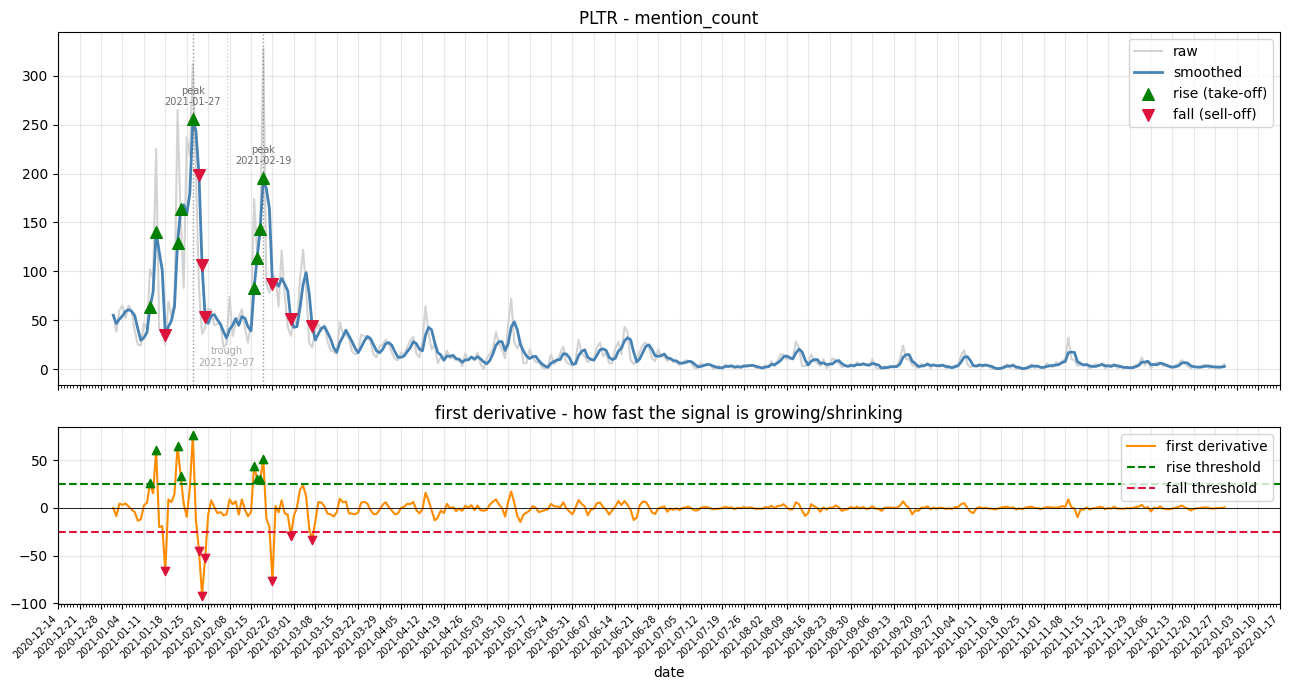


TSLA (mention_count): 12 rise day(s), 8 fall day(s), 2 peak(s), 1 trough(s)
    RISE   2021-01-06 | value 73 | velocity 17.0
    RISE   2021-01-07 | value 102 | velocity 16.0
    RISE   2021-01-08 | value 191 | velocity 48.7
    RISE   2021-01-09 | value 124 | velocity 17.0
    RISE   2021-01-27 | value 155 | velocity 37.3
    RISE   2021-01-28 | value 176 | velocity 26.0
    RISE   2021-02-23 | value 96 | velocity 25.7
    RISE   2021-02-24 | value 66 | velocity 15.7
    RISE   2021-03-05 | value 77 | velocity 17.7
    RISE   2021-05-13 | value 62 | velocity 16.3
    RISE   2021-10-25 | value 89 | velocity 25.0
    RISE   2021-10-26 | value 63 | velocity 18.0
    FALL   2021-01-11 | value 87 | velocity -34.7
    FALL   2021-01-30 | value 81 | velocity -24.7
    FALL   2021-01-31 | value 43 | velocity -44.3
    FALL   2021-02-01 | value 64 | velocity -16.3
    FALL   2021-02-26 | value 36 | velocity -20.0
    FALL   2021-02-27 | value 15 | velocity -17.0
    FALL   2021-03-12 | value 

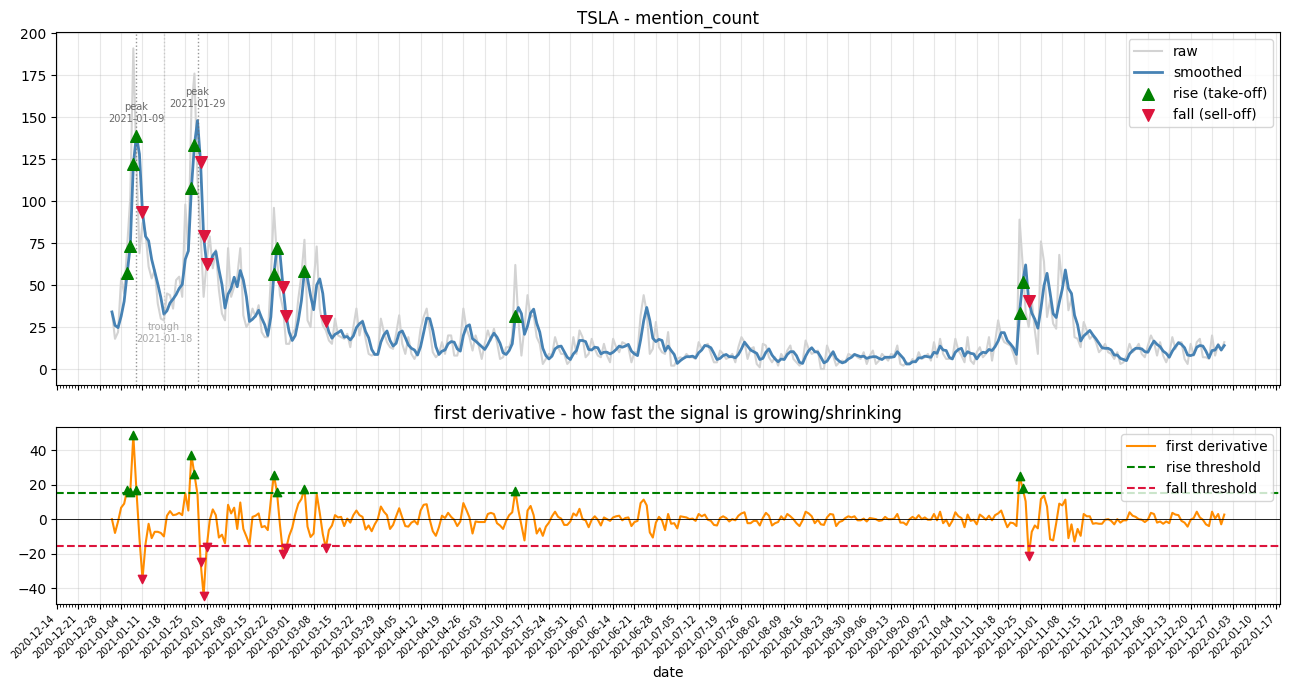


BB (mention_count): 5 rise day(s), 4 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-25 | value 433 | velocity 91.3
    RISE   2021-01-26 | value 480 | velocity 134.0
    RISE   2021-01-27 | value 913 | velocity 284.0
    RISE   2021-01-28 | value 1116 | velocity 227.7
    RISE   2021-06-03 | value 228 | velocity 74.3
    FALL   2021-01-30 | value 243 | velocity -223.3
    FALL   2021-01-31 | value 178 | velocity -312.7
    FALL   2021-02-01 | value 256 | velocity -105.7
    FALL   2021-06-06 | value 35 | velocity -64.3
    PEAK   2021-01-29


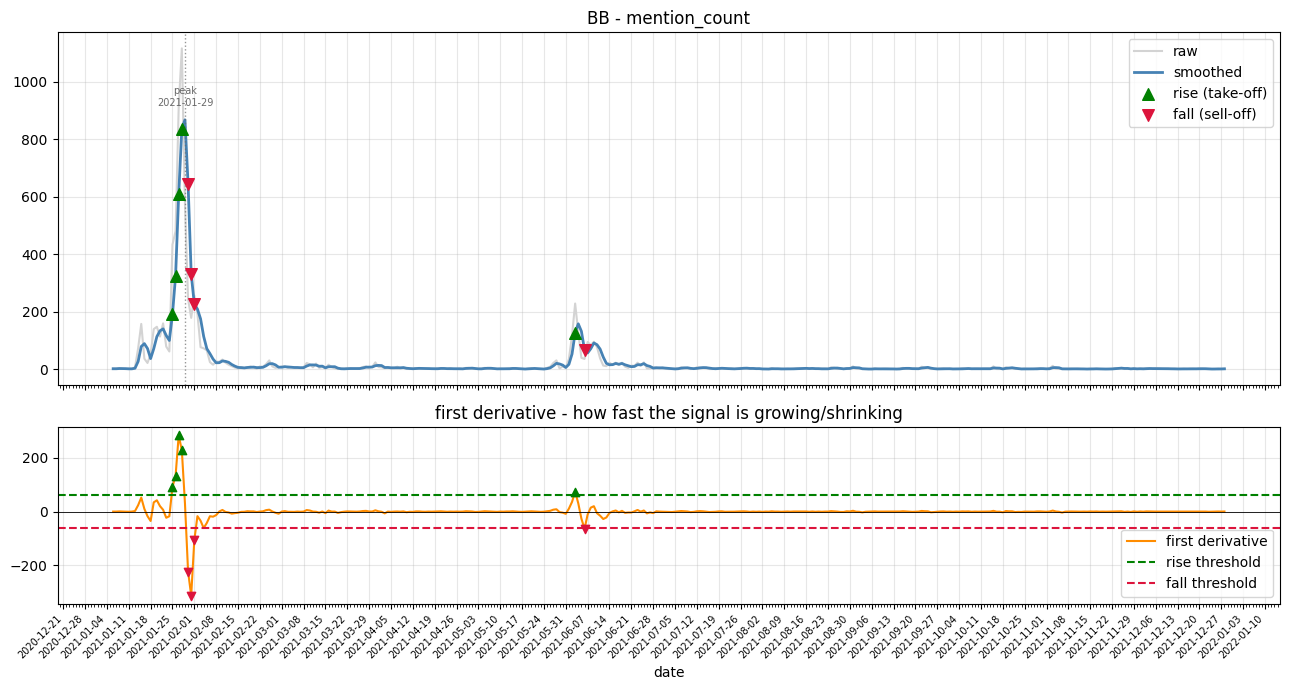


CLOV (mention_count): 4 rise day(s), 3 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-04-16 | value 225 | velocity 74.7
    RISE   2021-06-08 | value 805 | velocity 259.0
    RISE   2021-06-09 | value 693 | velocity 219.7
    RISE   2021-06-10 | value 351 | velocity 60.3
    FALL   2021-06-11 | value 192 | velocity -204.3
    FALL   2021-06-12 | value 86 | velocity -202.3
    FALL   2021-06-13 | value 56 | velocity -98.3
    PEAK   2021-06-10


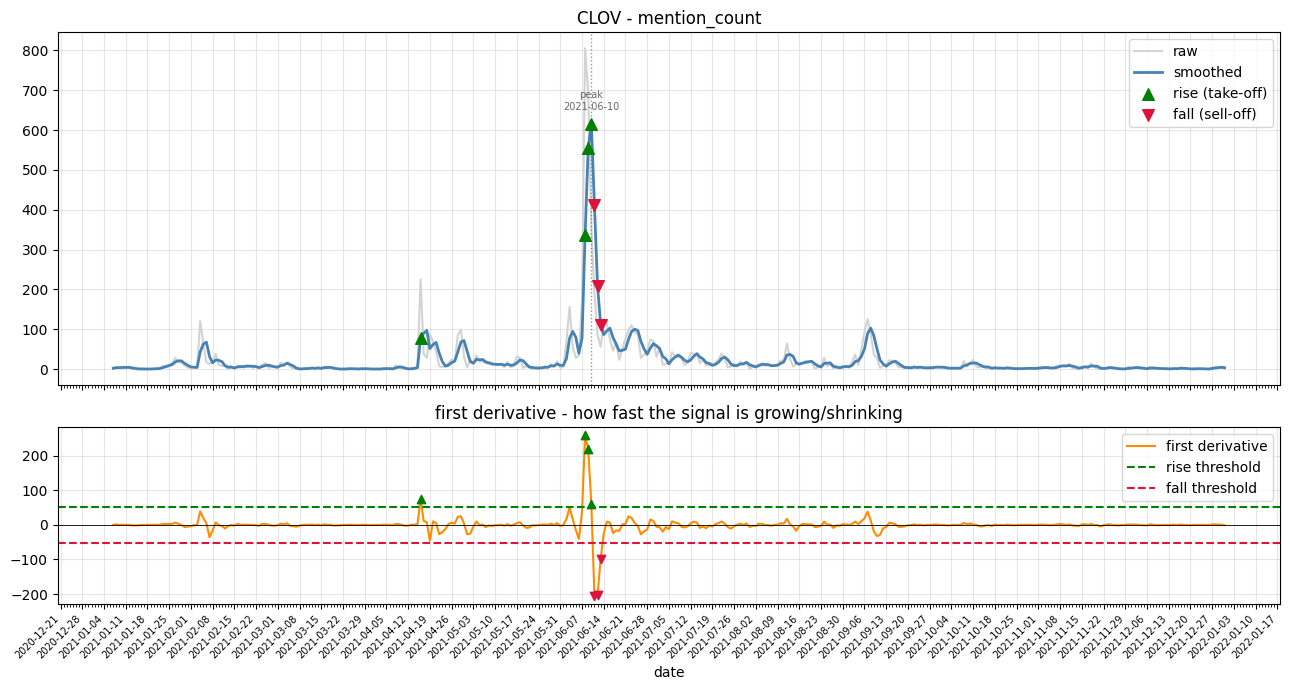


NAKD (mention_count): 3 rise day(s), 3 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-27 | value 982 | velocity 327.3
    RISE   2021-01-28 | value 2131 | velocity 708.3
    RISE   2021-01-29 | value 761 | velocity 251.3
    FALL   2021-01-30 | value 225 | velocity -252.3
    FALL   2021-01-31 | value 188 | velocity -647.7
    FALL   2021-02-01 | value 348 | velocity -137.7
    PEAK   2021-01-29


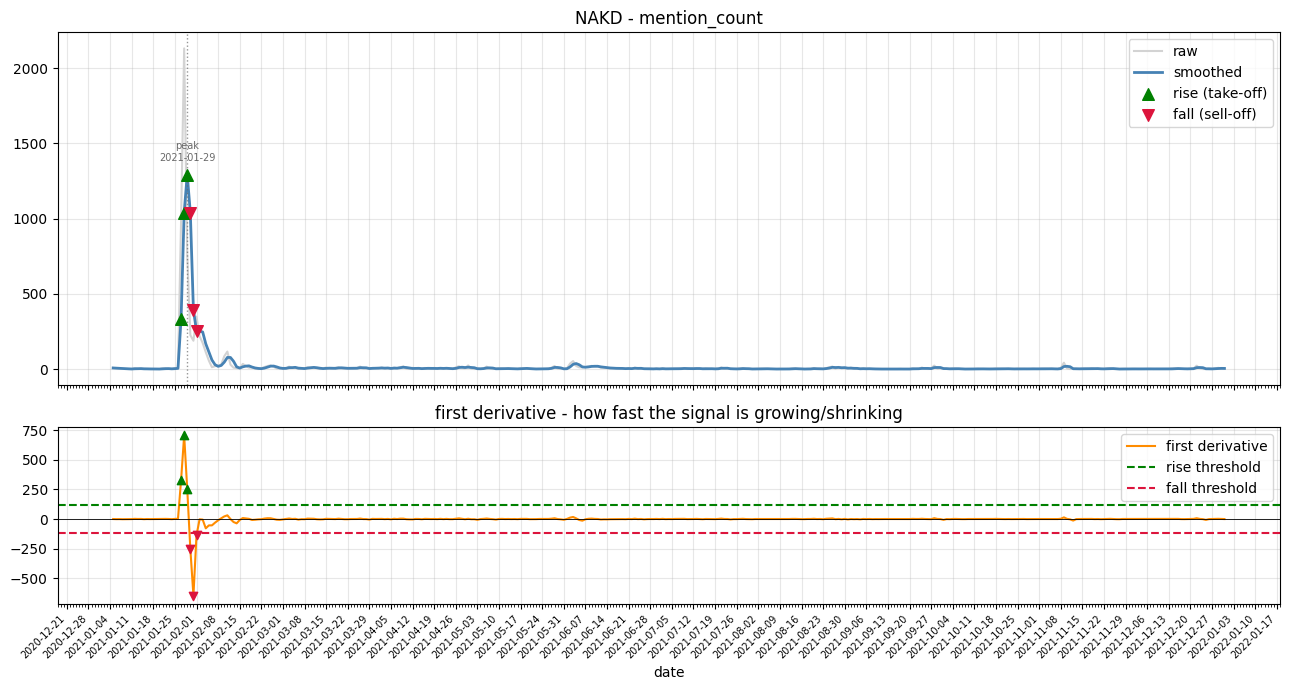


NOK (mention_count): 4 rise day(s), 4 fall day(s), 1 peak(s), 0 trough(s)
    RISE   2021-01-26 | value 240 | velocity 77.0
    RISE   2021-01-27 | value 988 | velocity 327.0
    RISE   2021-01-28 | value 1143 | velocity 317.0
    RISE   2021-01-29 | value 560 | velocity 106.7
    FALL   2021-01-30 | value 193 | velocity -265.0
    FALL   2021-01-31 | value 155 | velocity -329.3
    FALL   2021-02-01 | value 281 | velocity -93.0
    FALL   2021-02-05 | value 52 | velocity -94.3
    PEAK   2021-01-29


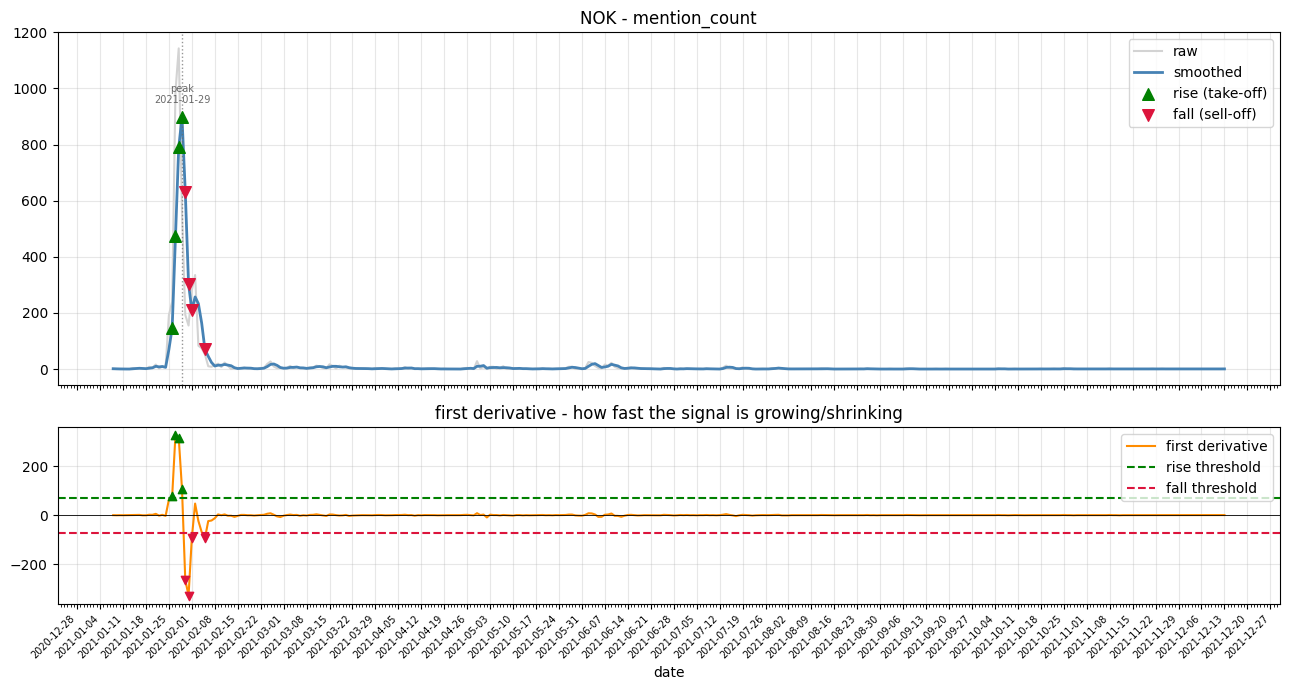


SPCE (mention_count): 6 rise day(s), 5 fall day(s), 2 peak(s), 2 trough(s)
    RISE   2021-01-26 | value 92 | velocity 26.7
    RISE   2021-01-27 | value 323 | velocity 106.7
    RISE   2021-01-28 | value 265 | velocity 75.0
    RISE   2021-05-24 | value 94 | velocity 26.0
    RISE   2021-06-25 | value 114 | velocity 31.0
    RISE   2021-07-12 | value 124 | velocity 24.7
    FALL   2021-01-30 | value 61 | velocity -87.3
    FALL   2021-01-31 | value 50 | velocity -71.7
    FALL   2021-02-04 | value 65 | velocity -24.3
    FALL   2021-06-28 | value 43 | velocity -23.7
    FALL   2021-07-15 | value 19 | velocity -35.0
    PEAK   2021-01-29
    PEAK   2021-07-13
    TROUGH 2021-04-05
    TROUGH 2021-04-25


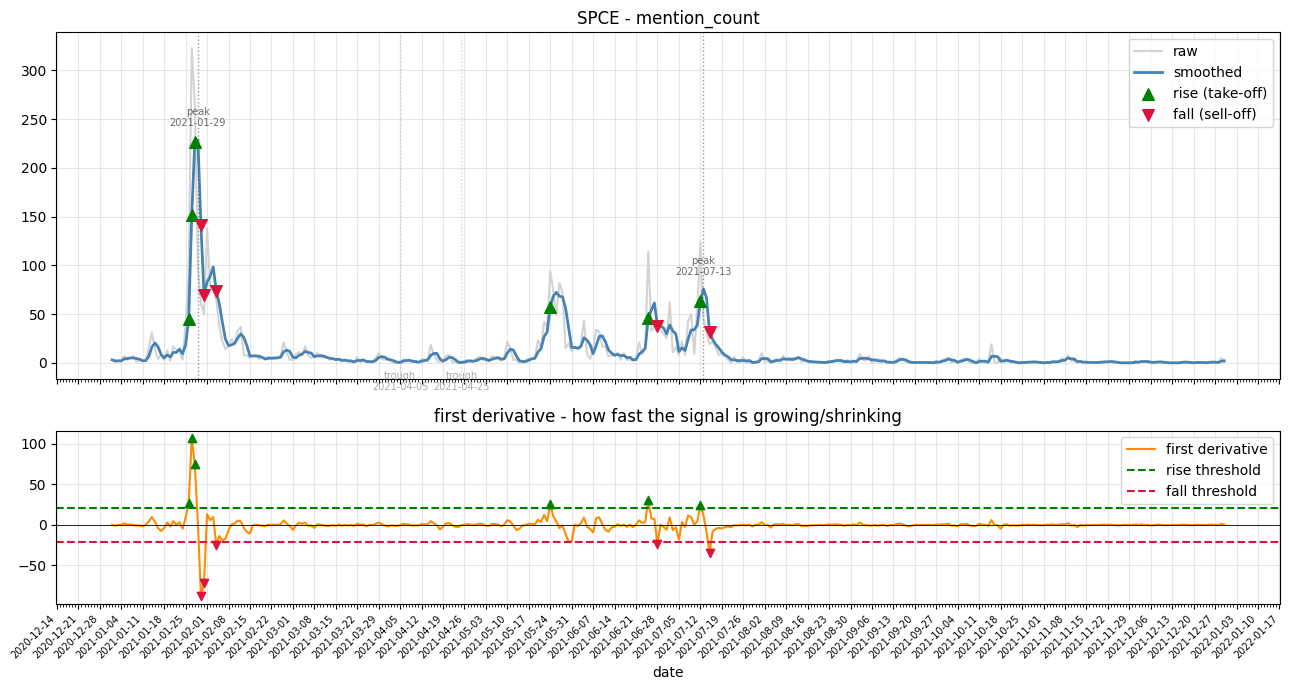

In [5]:
for ticker in chosen:
    series = build_daily_series(daily, ticker, value_col=VALUE_COLUMN)
    if series is None:
        print('skip', ticker, '(not found)'); continue
    result = compute_inflection(series, SMOOTH, K)
    rises = result[result['is_rise']]
    falls = result[result['is_fall']]
    peaks = result[result['is_peak']]
    troughs = result[result['is_trough']]

    print(f'\n{ticker} ({VALUE_COLUMN}): {len(rises)} rise day(s), {len(falls)} fall day(s), '
          f'{len(peaks)} peak(s), {len(troughs)} trough(s)')
    for date, row in rises.iterrows():
        print('    RISE  ', date.strftime('%Y-%m-%d'), '| value', int(row['count']), '| velocity', round(row['velocity'], 1))
    for date, row in falls.iterrows():
        print('    FALL  ', date.strftime('%Y-%m-%d'), '| value', int(row['count']), '| velocity', round(row['velocity'], 1))
    for date in peaks.index:
        print('    PEAK  ', date.strftime('%Y-%m-%d'))
    for date in troughs.index:
        print('    TROUGH', date.strftime('%Y-%m-%d'))

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

    # --- Top: raw + smoothed mentions ---
    top.plot(result.index, result['count'], color='lightgray', label='raw')
    top.plot(result.index, result['smoothed'], color='steelblue', linewidth=2, label='smoothed')
    top.scatter(rises.index, rises['smoothed'], color='green', marker='^', s=70, zorder=5, label='rise (take-off)')
    top.scatter(falls.index, falls['smoothed'], color='crimson', marker='v', s=70, zorder=5, label='fall (sell-off)')

    # Peaks/troughs = where the trend itself turns (concavity change: the
    # smoothed line stops rising and starts falling, or vice versa).
    # Each label carries its EXACT date so no squinting at the axis.
    for date in peaks.index:
        top.axvline(date, color='dimgray', linestyle=':', linewidth=1, alpha=0.7)
        top.annotate(f"peak\n{date:%Y-%m-%d}", (date, result.loc[date, 'smoothed']),
                     textcoords='offset points', xytext=(0, 10), ha='center',
                     fontsize=7, color='dimgray')
    for date in troughs.index:
        top.axvline(date, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
        top.annotate(f"trough\n{date:%Y-%m-%d}", (date, result.loc[date, 'smoothed']),
                     textcoords='offset points', xytext=(0, -20), ha='center',
                     fontsize=7, color='darkgray')

    top.set_title(f'{ticker} - {VALUE_COLUMN}'); top.legend(); top.grid(True, alpha=0.3)
    top.tick_params(labelbottom=False)   # dates only need to appear once, on the shared axis below

    bottom.plot(result.index, result['velocity'], color='darkorange', label='first derivative')
    bottom.axhline(result.attrs['threshold'], color='green', linestyle='--', label='rise threshold')
    bottom.axhline(result.attrs['fall_threshold'], color='crimson', linestyle='--', label='fall threshold')
    bottom.axhline(0, color='black', linewidth=0.6)
    bottom.scatter(rises.index, rises['velocity'], color='green', marker='^', zorder=5)
    bottom.scatter(falls.index, falls['velocity'], color='crimson', marker='v', zorder=5)
    bottom.set_title('first derivative - how fast the signal is growing/shrinking'); bottom.legend(); bottom.grid(True, alpha=0.3)
    bottom.set_xlabel('date')
    format_date_axis(bottom)   # dense, exact YYYY-MM-DD ticks, rotated for readability
    plt.tight_layout(); plt.show()

## Per-year view - top 10 tickers, one plot per year

Each year gets its **own figure** with that year's top 10 tickers. The
inflection threshold (`mean + K x std`) is computed **within the year**, so a
ticker's take-off is judged against that year's normal noise - old
high-volume years don't drown out newer ones.

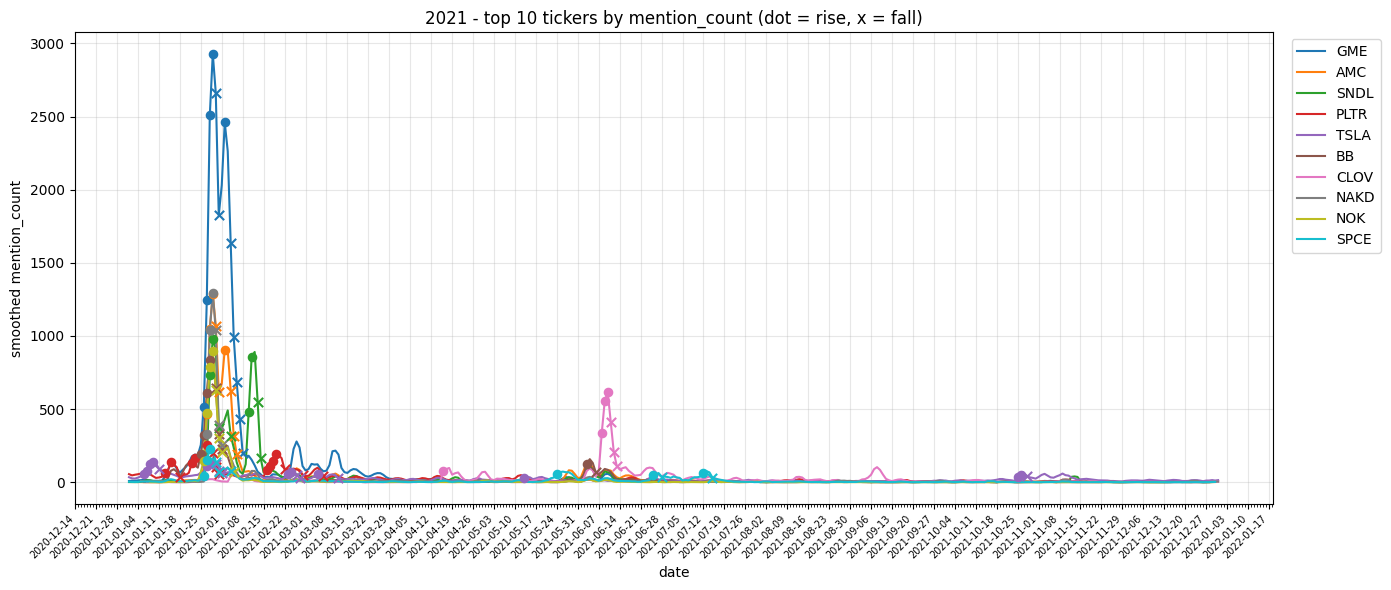

In [6]:
# One figure per year: smoothed signal for the year's top 10 tickers,
# with that year's rise days (dot) and fall days (x) marked in the line's colour.
YEARLY_TOP_N = 10

daily['year'] = daily['date'].dt.year

for year in sorted(daily['year'].unique()):
    year_df = daily[daily['year'] == year]
    totals = year_df.groupby('ticker')[VALUE_COLUMN].sum().sort_values(ascending=False)
    top = list(totals.head(YEARLY_TOP_N).index)
    if not top:
        continue

    fig, ax = plt.subplots(figsize=(14, 6))
    for ticker in top:
        series = build_daily_series(year_df, ticker, value_col=VALUE_COLUMN)
        if series is None:
            continue
        result = compute_inflection(series, SMOOTH, K)   # threshold = THIS year's noise
        line, = ax.plot(result.index, result['smoothed'], linewidth=1.5, label=ticker)
        rises = result[result['is_rise']]
        falls = result[result['is_fall']]
        ax.scatter(rises.index, rises['smoothed'], color=line.get_color(), marker='o', s=35, zorder=5)
        ax.scatter(falls.index, falls['smoothed'], color=line.get_color(), marker='x', s=45, zorder=5)

    ax.set_title(f'{year} - top {len(top)} tickers by {VALUE_COLUMN} (dot = rise, x = fall)')
    ax.set_xlabel('date'); ax.set_ylabel(f'smoothed {VALUE_COLUMN}')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    format_date_axis(ax)   # dense, exact YYYY-MM-DD ticks, rotated for readability
    plt.tight_layout()
    plt.show()

## Why is the velocity so jagged? (and the fix)

Three reasons the first-derivative plot looks like a saw blade:

1. **Differencing amplifies noise.** The derivative is `today - yesterday`. If
   the count wobbles by +-3 posts around its average, the *derivative* wobbles
   by +-6. Any noise in the level gets doubled in the slope.
2. **The smoothing window is tiny.** `SMOOTH = 3` averages just 3 days - not
   enough to kill the weekday/weekend cycle (Reddit is quieter on weekends,
   so every Monday looks like a mini take-off).
3. **Counts are small integers.** Away from meme events a ticker gets 0-5
   mentions a day, so the series jumps between whole numbers - inherently
   jagged. And when a viral day DOES happen (3,000 mentions), it stretches
   the y-axis so everything else looks flat.

**The fix below uses three standard tricks:**

- **log(1+count)** - squashes viral spikes so the y-axis isn't dominated by
  one day. Bonus: the derivative of a log is (approximately) the **daily
  percentage growth rate**, which is comparable across tickers big and small.
- **EWMA smoothing** (exponentially weighted moving average, span ~14 days) -
  much smoother than a 3-day average, but still reacts faster than a plain
  14-day average because recent days get more weight.
- **A minimum-volume filter** - tickers with only a handful of mentions total
  can never produce a meaningful trend line; we skip them.

Tune `EWMA_SPAN` to taste: bigger = smoother line and cleaner inflection
points, but the take-off is flagged a day or two later.

analysing (>= 300 total mentions): ['GME', 'AMC', 'SNDL', 'PLTR', 'TSLA', 'BB', 'CLOV', 'NAKD', 'NOK', 'SPCE']

GME: 6 rise day(s), 0 fall day(s), 3 peak(s), 2 trough(s) on the smooth signal
    RISE   2021-01-13 | count that day 82
    RISE   2021-01-14 | count that day 154
    RISE   2021-01-15 | count that day 147
    RISE   2021-01-26 | count that day 914
    RISE   2021-01-27 | count that day 2327
    RISE   2021-01-28 | count that day 4281
    PEAK   2021-02-03
    PEAK   2021-06-11
    PEAK   2021-11-05
    TROUGH 2021-05-23
    TROUGH 2021-10-03


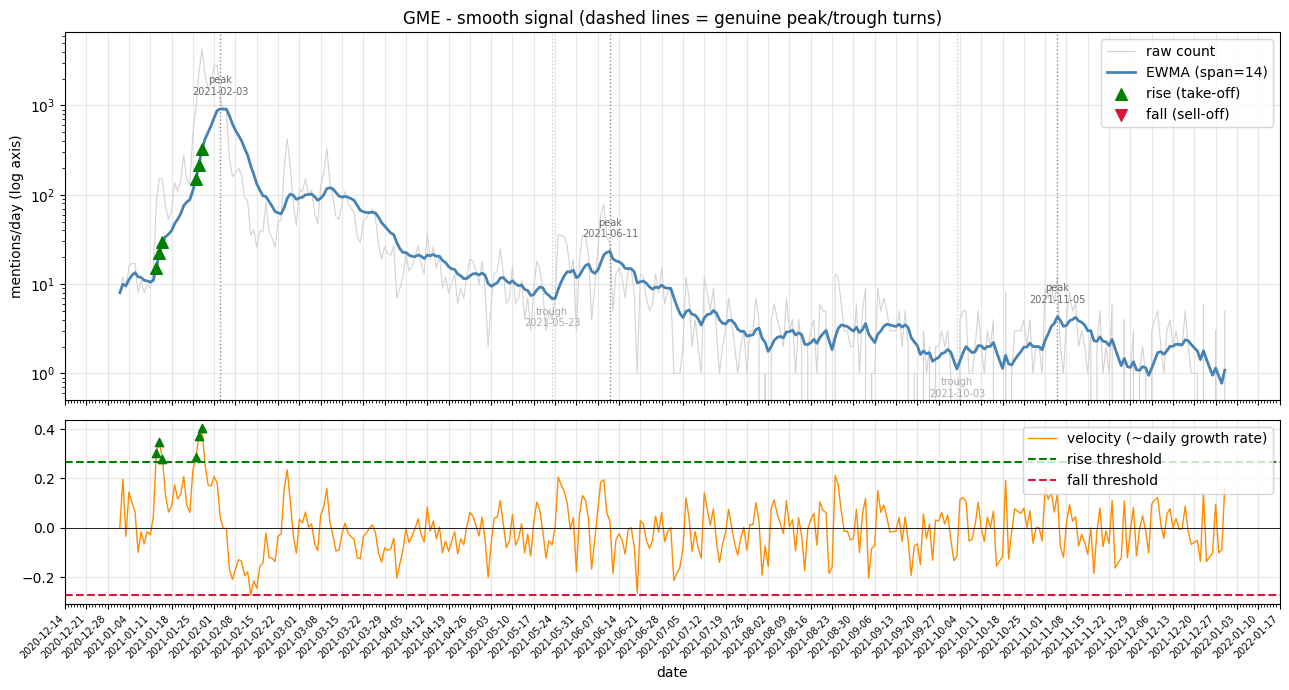


AMC: 7 rise day(s), 2 fall day(s), 2 peak(s), 1 trough(s) on the smooth signal
    RISE   2021-01-15 | count that day 21
    RISE   2021-01-25 | count that day 104
    RISE   2021-01-26 | count that day 172
    RISE   2021-01-27 | count that day 1127
    RISE   2021-01-28 | count that day 1848
    RISE   2021-01-29 | count that day 884
    RISE   2021-05-27 | count that day 99
    FALL   2021-01-05 | count that day 0
    FALL   2021-07-17 | count that day 0
    PEAK   2021-02-05
    PEAK   2021-06-11
    TROUGH 2021-04-25


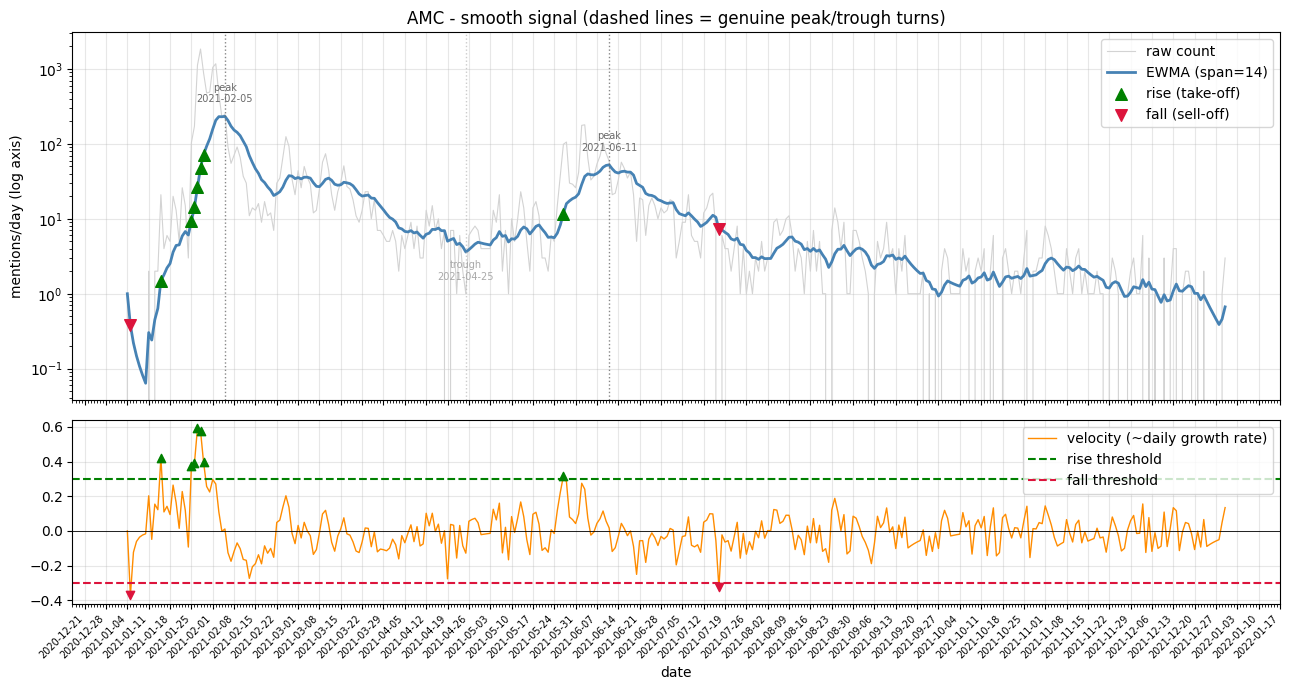


SNDL: 7 rise day(s), 2 fall day(s), 3 peak(s), 2 trough(s) on the smooth signal
    RISE   2021-01-05 | count that day 9
    RISE   2021-01-06 | count that day 16
    RISE   2021-01-27 | count that day 376
    RISE   2021-01-28 | count that day 1795
    RISE   2021-01-29 | count that day 758
    RISE   2021-02-01 | count that day 743
    RISE   2021-11-12 | count that day 96
    FALL   2021-01-02 | count that day 0
    FALL   2021-07-03 | count that day 0
    PEAK   2021-02-12
    PEAK   2021-06-09
    PEAK   2021-11-21
    TROUGH 2021-05-23
    TROUGH 2021-10-04


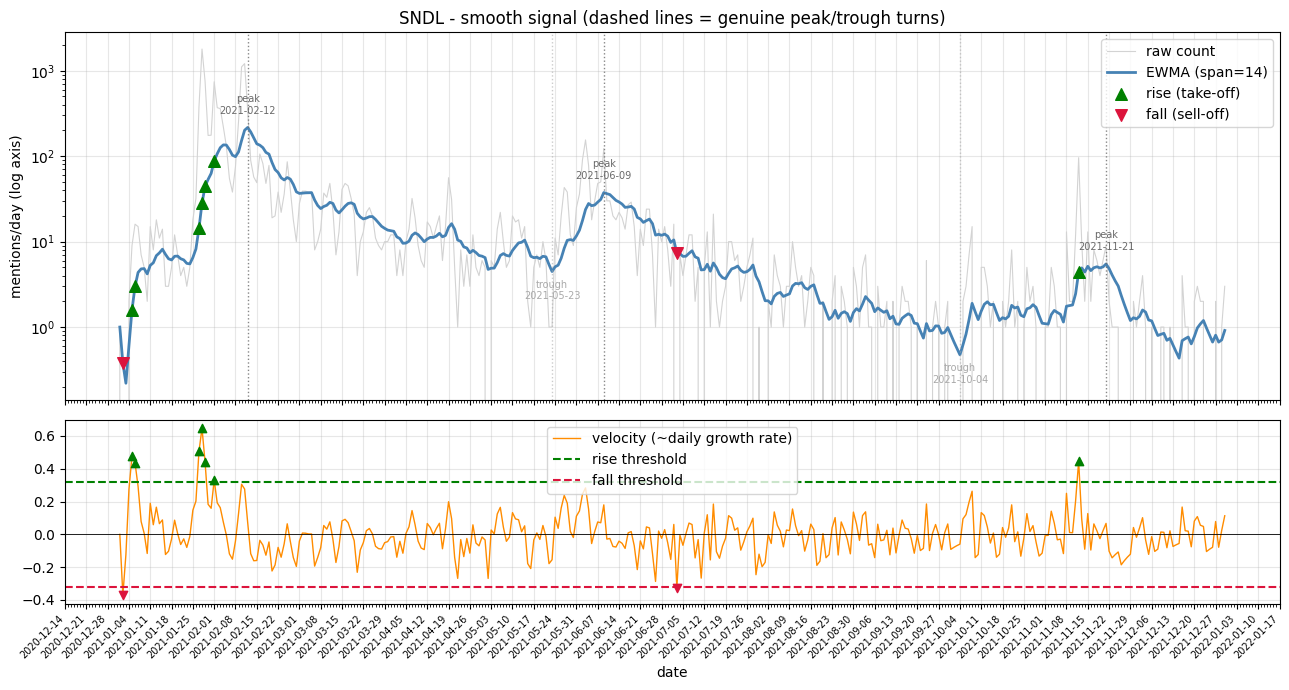


PLTR: 2 rise day(s), 4 fall day(s), 5 peak(s), 4 trough(s) on the smooth signal
    RISE   2021-09-16 | count that day 24
    RISE   2021-11-09 | count that day 32
    FALL   2021-05-02 | count that day 0
    FALL   2021-05-22 | count that day 0
    FALL   2021-07-16 | count that day 0
    FALL   2021-11-16 | count that day 0
    PEAK   2021-01-28
    PEAK   2021-05-14
    PEAK   2021-06-18
    PEAK   2021-08-13
    PEAK   2021-11-11
    TROUGH 2021-05-02
    TROUGH 2021-05-23
    TROUGH 2021-08-01
    TROUGH 2021-10-26


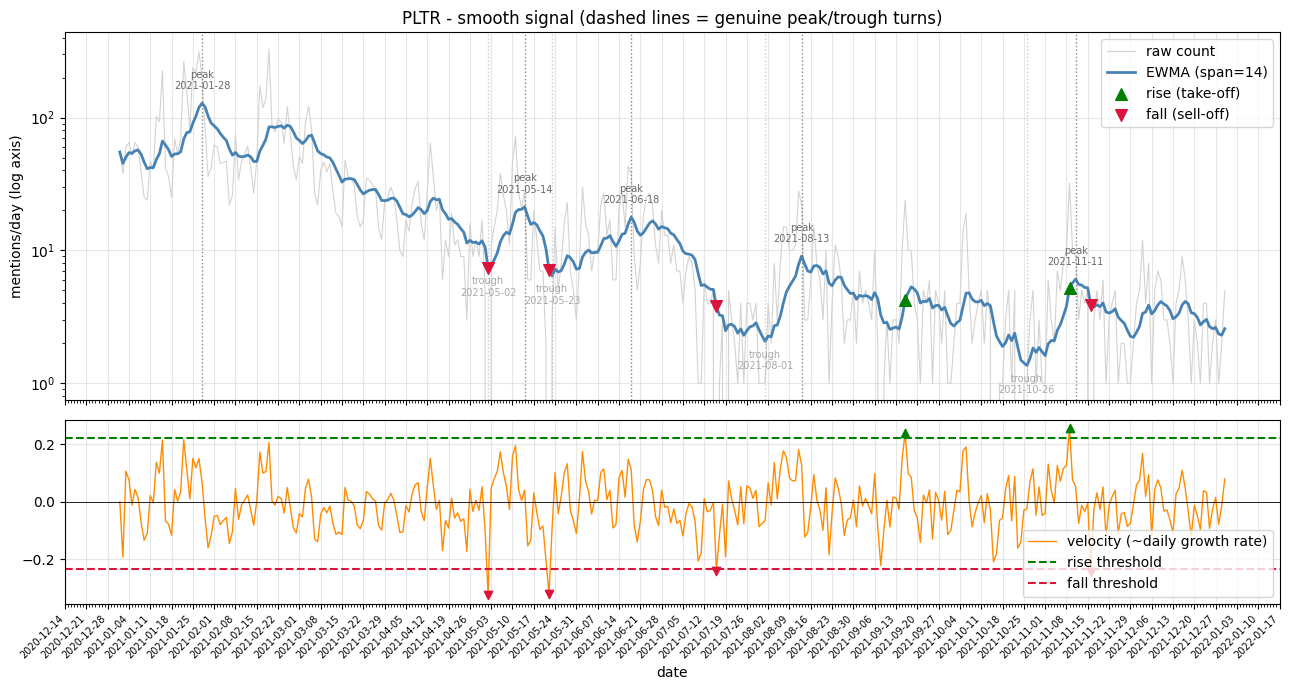


TSLA: 3 rise day(s), 6 fall day(s), 2 peak(s), 1 trough(s) on the smooth signal
    RISE   2021-01-04 | count that day 54
    RISE   2021-01-08 | count that day 191
    RISE   2021-10-25 | count that day 89
    FALL   2021-01-02 | count that day 18
    FALL   2021-05-22 | count that day 3
    FALL   2021-07-03 | count that day 2
    FALL   2021-08-01 | count that day 1
    FALL   2021-08-21 | count that day 0
    FALL   2021-08-22 | count that day 0
    PEAK   2021-01-30
    PEAK   2021-11-11
    TROUGH 2021-08-22


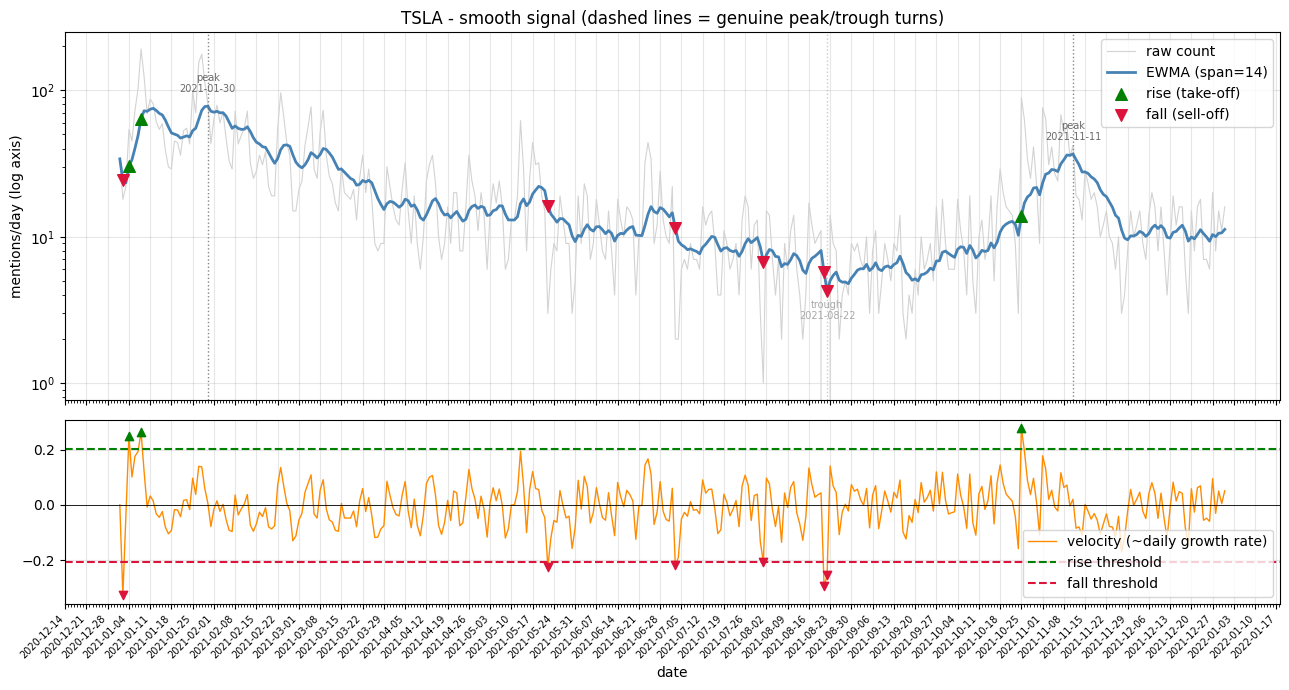


BB: 6 rise day(s), 0 fall day(s), 2 peak(s), 1 trough(s) on the smooth signal
    RISE   2021-01-14 | count that day 72
    RISE   2021-01-15 | count that day 157
    RISE   2021-01-19 | count that day 139
    RISE   2021-01-27 | count that day 913
    RISE   2021-06-02 | count that day 117
    RISE   2021-06-03 | count that day 228
    PEAK   2021-02-01
    PEAK   2021-06-10
    TROUGH 2021-05-24


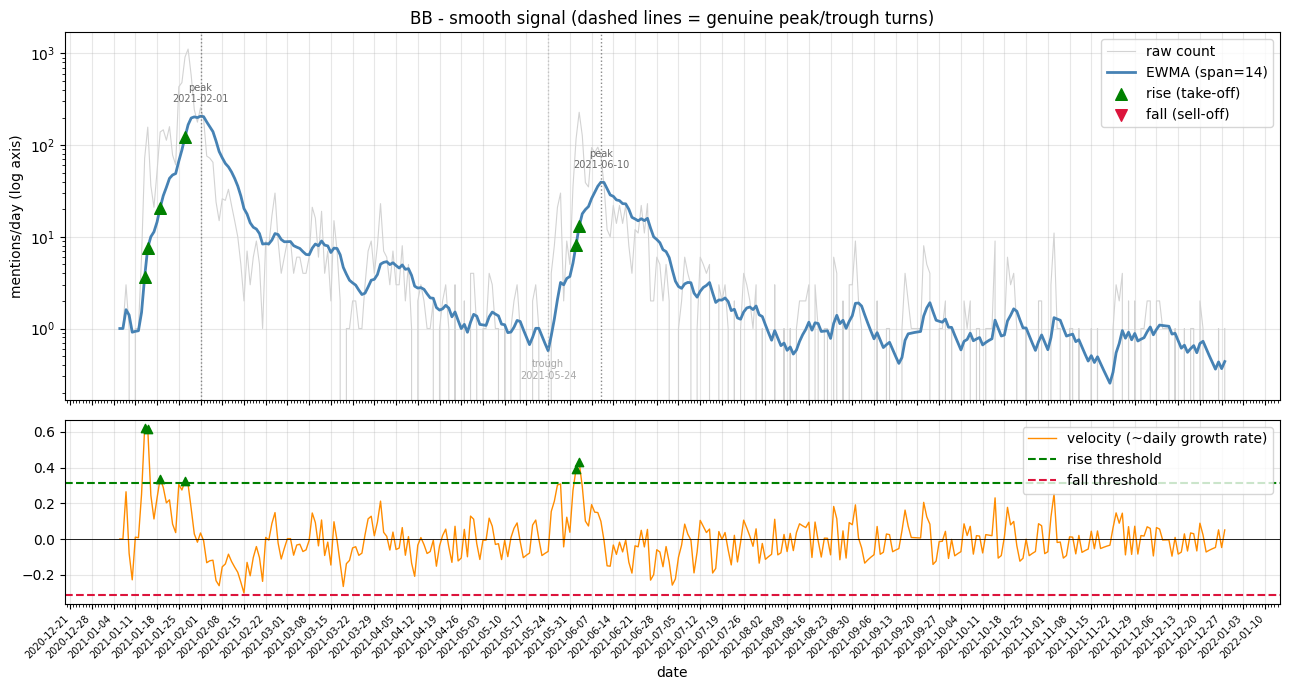


CLOV: 7 rise day(s), 3 fall day(s), 5 peak(s), 5 trough(s) on the smooth signal
    RISE   2021-01-08 | count that day 5
    RISE   2021-02-04 | count that day 120
    RISE   2021-04-16 | count that day 225
    RISE   2021-04-19 | count that day 88
    RISE   2021-06-03 | count that day 156
    RISE   2021-06-08 | count that day 805
    RISE   2021-06-09 | count that day 693
    FALL   2021-01-13 | count that day 0
    FALL   2021-02-13 | count that day 0
    FALL   2021-07-31 | count that day 0
    PEAK   2021-02-09
    PEAK   2021-04-30
    PEAK   2021-06-15
    PEAK   2021-09-10
    PEAK   2021-11-19
    TROUGH 2021-01-19
    TROUGH 2021-04-03
    TROUGH 2021-05-27
    TROUGH 2021-09-01
    TROUGH 2021-10-27


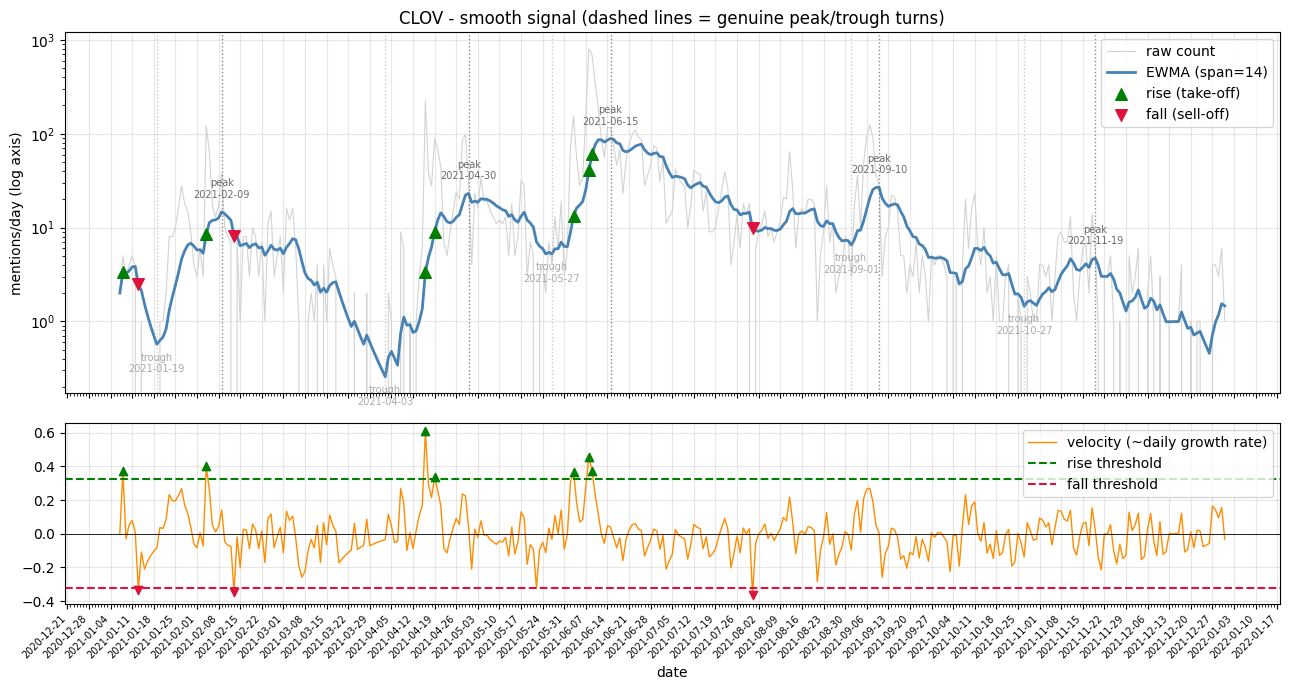


NAKD: 4 rise day(s), 1 fall day(s), 5 peak(s), 6 trough(s) on the smooth signal
    RISE   2021-01-27 | count that day 982
    RISE   2021-01-28 | count that day 2131
    RISE   2021-01-29 | count that day 761
    RISE   2021-11-09 | count that day 42
    FALL   2021-02-21 | count that day 0
    PEAK   2021-02-04
    PEAK   2021-06-11
    PEAK   2021-09-01
    PEAK   2021-09-30
    PEAK   2021-11-10
    TROUGH 2021-01-20
    TROUGH 2021-05-25
    TROUGH 2021-08-11
    TROUGH 2021-09-20
    TROUGH 2021-11-01
    TROUGH 2021-12-13


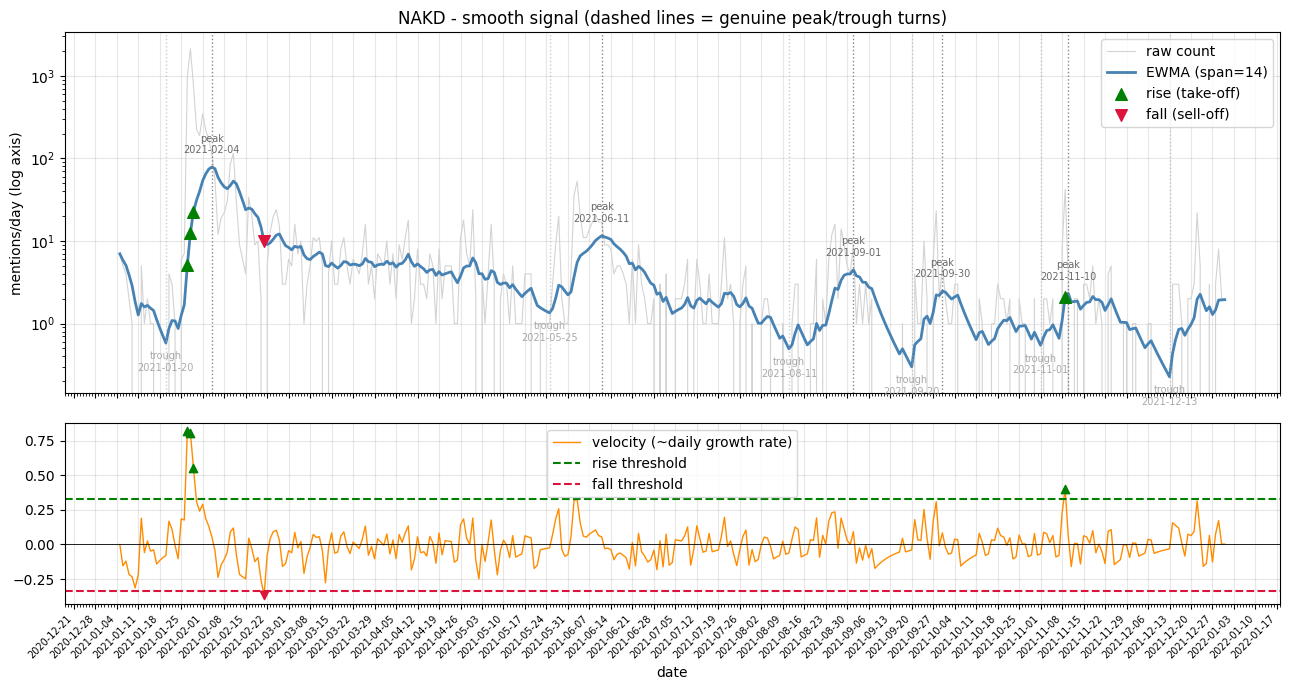


NOK: 7 rise day(s), 2 fall day(s), 3 peak(s), 2 trough(s) on the smooth signal
    RISE   2021-01-25 | count that day 192
    RISE   2021-01-26 | count that day 240
    RISE   2021-01-27 | count that day 988
    RISE   2021-01-28 | count that day 1143
    RISE   2021-01-29 | count that day 560
    RISE   2021-04-29 | count that day 28
    RISE   2021-06-02 | count that day 25
    FALL   2021-01-09 | count that day 0
    FALL   2021-02-13 | count that day 0
    PEAK   2021-02-02
    PEAK   2021-05-07
    PEAK   2021-06-10
    TROUGH 2021-04-24
    TROUGH 2021-05-22


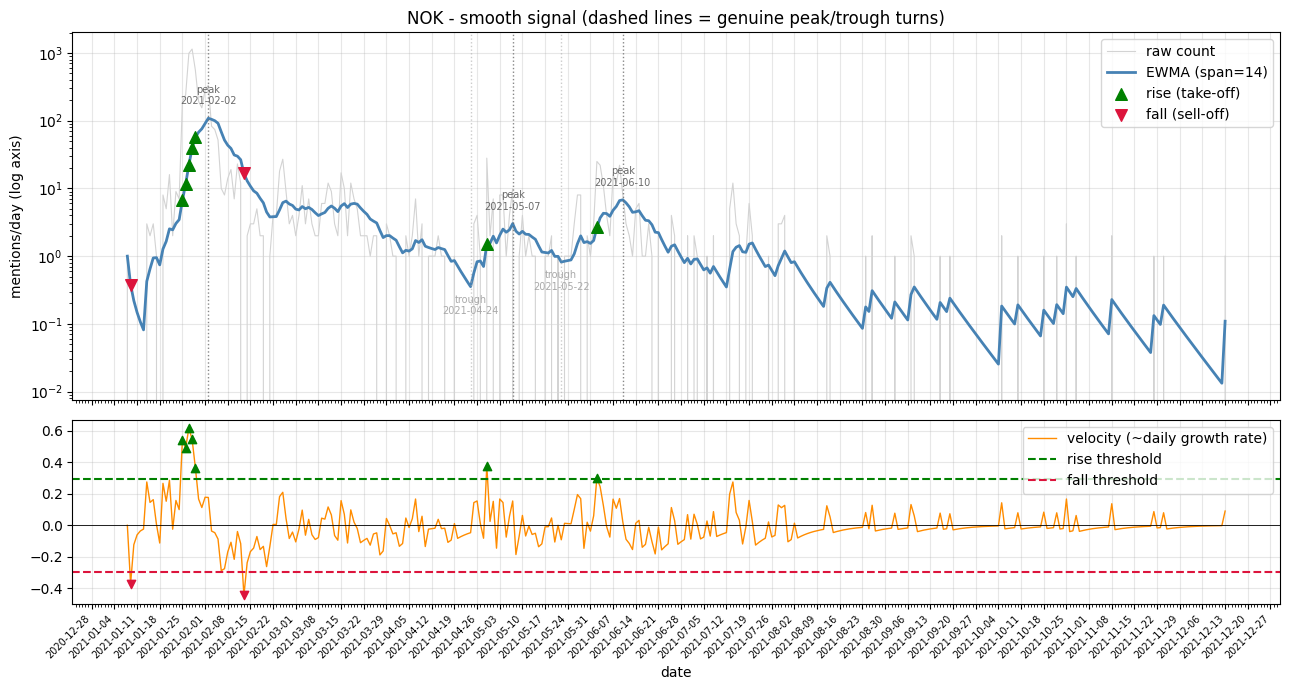


SPCE: 7 rise day(s), 2 fall day(s), 3 peak(s), 2 trough(s) on the smooth signal
    RISE   2021-01-14 | count that day 31
    RISE   2021-01-26 | count that day 92
    RISE   2021-01-27 | count that day 323
    RISE   2021-01-28 | count that day 265
    RISE   2021-05-24 | count that day 94
    RISE   2021-06-25 | count that day 114
    RISE   2021-10-15 | count that day 19
    FALL   2021-01-02 | count that day 1
    FALL   2021-07-22 | count that day 0
    PEAK   2021-02-04
    PEAK   2021-05-28
    PEAK   2021-07-14
    TROUGH 2021-04-11
    TROUGH 2021-06-21


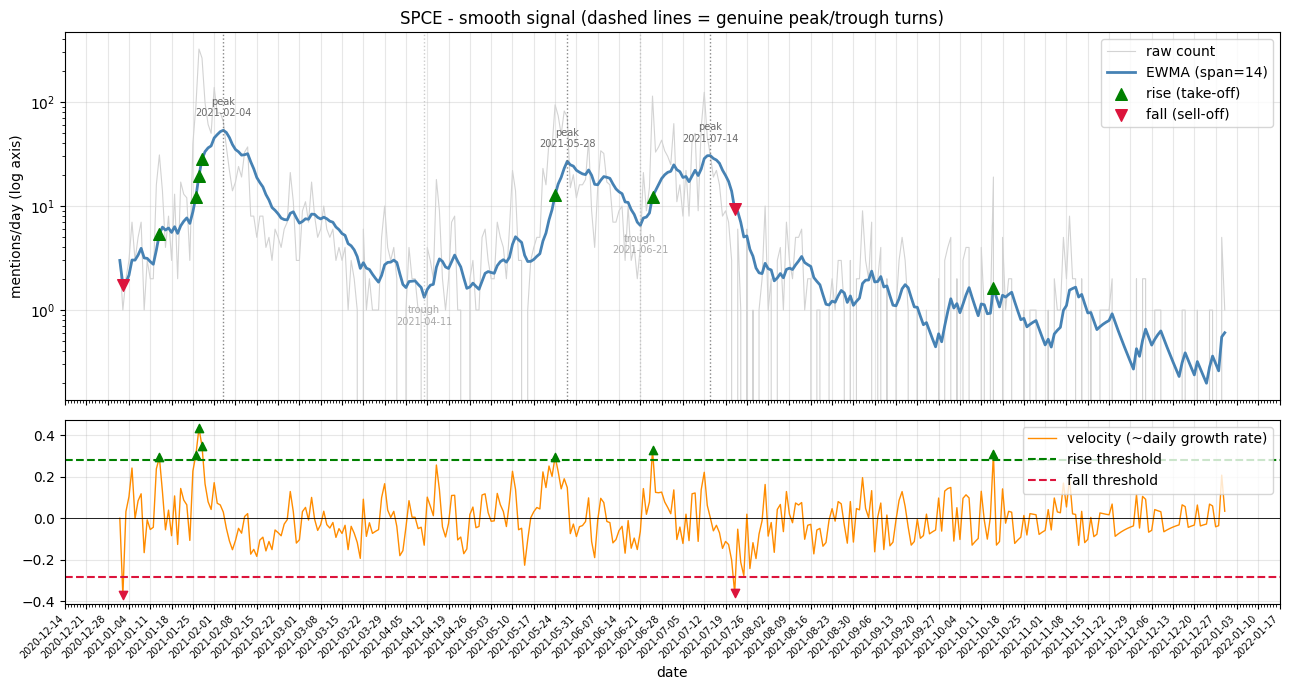

In [7]:
# ============ SMOOTHER SIGNAL - parameters ============
EWMA_SPAN  = 14     # smoothing strength: try 7 (reactive) to 30 (very smooth)
USE_LOG    = True   # analyse log(1+count): tames spikes, velocity ~= % growth
MIN_TOTAL  = 300    # skip tickers with fewer total mentions than this
K_SMOOTH   = 2.5    # spike threshold on the smooth signal (higher = stricter)
PEAK_PROMINENCE = 0.75   # min log-scale height a local high/low needs to count
                         # as a real peak/trough (bigger = fewer, bolder turns)
# ======================================================
import numpy as np
from scipy.signal import find_peaks

def smooth_inflection(series, span, k, use_log, peak_prominence):
    """Same idea as compute_inflection, but EWMA-smoothed and optionally
    on a log scale. Returns count, smoothed, velocity, is_rise, is_fall,
    is_peak, is_trough."""
    values = series.astype(float)
    if use_log:
        values = np.log1p(values)          # log(1 + count)
    out = pd.DataFrame({'count': series})
    out['smoothed'] = values.ewm(span=span).mean()
    out['velocity'] = out['smoothed'].diff().fillna(0)

    average_change = out['velocity'].mean()
    spread = out['velocity'].std()
    rise_threshold = average_change + k * spread
    fall_threshold = average_change - k * spread
    out['is_rise'] = (out['velocity'] > rise_threshold) & (out['velocity'] > 0)
    out['is_fall'] = (out['velocity'] < fall_threshold) & (out['velocity'] < 0)

    # Peaks/troughs: prominent local turns of the EWMA line - the "rose
    # here, fell here" moments - filtered by scipy's peak prominence so
    # everyday noise doesn't get flagged as a turning point.
    smoothed_vals = out['smoothed'].to_numpy()
    peak_idx, _ = find_peaks(smoothed_vals, prominence=peak_prominence)
    trough_idx, _ = find_peaks(-smoothed_vals, prominence=peak_prominence)
    out['is_peak'] = False
    out['is_trough'] = False
    out.iloc[peak_idx, out.columns.get_loc('is_peak')] = True
    out.iloc[trough_idx, out.columns.get_loc('is_trough')] = True

    out.attrs['threshold'] = rise_threshold
    out.attrs['fall_threshold'] = fall_threshold
    return out

# Skip sparse tickers - they can't produce a meaningful trend.
volume = daily.groupby('ticker')[VALUE_COLUMN].sum()
liquid = [t for t in chosen if volume.get(t, 0) >= MIN_TOTAL]
print('analysing (>=', MIN_TOTAL, 'total mentions):', liquid)

for ticker in liquid:
    series = build_daily_series(daily, ticker, value_col=VALUE_COLUMN)
    if series is None:
        continue
    result = smooth_inflection(series, EWMA_SPAN, K_SMOOTH, USE_LOG, PEAK_PROMINENCE)
    rises = result[result['is_rise']]
    falls = result[result['is_fall']]
    peaks = result[result['is_peak']]
    troughs = result[result['is_trough']]

    print(f'\n{ticker}: {len(rises)} rise day(s), {len(falls)} fall day(s), '
          f'{len(peaks)} peak(s), {len(troughs)} trough(s) on the smooth signal')
    for date, row in rises.iterrows():
        print('    RISE  ', date.strftime('%Y-%m-%d'), '| count that day', int(row['count']))
    for date, row in falls.iterrows():
        print('    FALL  ', date.strftime('%Y-%m-%d'), '| count that day', int(row['count']))
    for date in peaks.index:
        print('    PEAK  ', date.strftime('%Y-%m-%d'))
    for date in troughs.index:
        print('    TROUGH', date.strftime('%Y-%m-%d'))

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1]})
    # Top: raw counts (log axis so spikes don't flatten everything) + EWMA line.
    top.plot(result.index, result['count'], color='lightgray', linewidth=0.8, label='raw count')
    smooth_in_counts = np.expm1(result['smoothed']) if USE_LOG else result['smoothed']
    top.plot(result.index, smooth_in_counts, color='steelblue', linewidth=2, label=f'EWMA (span={EWMA_SPAN})')
    rise_y = np.expm1(rises['smoothed']) if USE_LOG else rises['smoothed']
    fall_y = np.expm1(falls['smoothed']) if USE_LOG else falls['smoothed']
    top.scatter(rises.index, rise_y, color='green', marker='^', s=70, zorder=5, label='rise (take-off)')
    top.scatter(falls.index, fall_y, color='crimson', marker='v', s=70, zorder=5, label='fall (sell-off)')
    # Each peak/trough label carries its EXACT date so no squinting at the axis.
    for date in peaks.index:
        top.axvline(date, color='dimgray', linestyle=':', linewidth=1, alpha=0.8)
        top.annotate(f"peak\n{date:%Y-%m-%d}", (date, smooth_in_counts.loc[date]),
                     textcoords='offset points', xytext=(0, 10), ha='center',
                     fontsize=7, color='dimgray')
    for date in troughs.index:
        top.axvline(date, color='darkgray', linestyle=':', linewidth=1, alpha=0.6)
        top.annotate(f"trough\n{date:%Y-%m-%d}", (date, smooth_in_counts.loc[date]),
                     textcoords='offset points', xytext=(0, -20), ha='center',
                     fontsize=7, color='darkgray')
    top.set_yscale('log'); top.set_ylabel('mentions/day (log axis)')
    top.set_title(f'{ticker} - smooth signal (dashed lines = genuine peak/trough turns)')
    top.legend(); top.grid(True, alpha=0.3)
    top.tick_params(labelbottom=False)   # dates only need to appear once, on the shared axis below
    # Bottom: velocity. In log mode this is roughly the daily GROWTH RATE.
    bottom.plot(result.index, result['velocity'], color='darkorange', linewidth=1,
                label='velocity (~daily growth rate)' if USE_LOG else 'velocity')
    bottom.axhline(result.attrs['threshold'], color='green', linestyle='--', label='rise threshold')
    bottom.axhline(result.attrs['fall_threshold'], color='crimson', linestyle='--', label='fall threshold')
    bottom.axhline(0, color='black', linewidth=0.6)
    bottom.scatter(rises.index, rises['velocity'], color='green', marker='^', zorder=5)
    bottom.scatter(falls.index, falls['velocity'], color='crimson', marker='v', zorder=5)
    bottom.set_xlabel('date')
    bottom.legend(); bottom.grid(True, alpha=0.3)
    format_date_axis(bottom)   # dense, exact YYYY-MM-DD ticks, rotated for readability
    plt.tight_layout(); plt.show()